In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
from collections import defaultdict
import json

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

BUNDLE_DIR = Path.cwd().resolve()
ROOT_DIR = BUNDLE_DIR.parents[0]
RESULTS_DIR = BUNDLE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = ROOT_DIR / "data"
PROTEIN_DATA_DIR = DATA_DIR / "protein" / "aggregated_all"
CELL_LINEAGE_PATH = DATA_DIR / "cell_lineage.json"
CELL_TYPE_PATH = DATA_DIR / "2023-06-29_entropy_cell_key_V2.csv"
S3_PATH = PROTEIN_DATA_DIR / "s3.csv"

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))

def map_names(did):
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

In [2]:
# ── Lineage tree & terminal/intermediate enumeration ──
with CELL_LINEAGE_PATH.open('r', encoding='utf-8') as f:
    lineage_data = json.load(f)
terminal_nodes = []
intermediate_nodes = []
descendant_list_dict = defaultdict(list)

def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if len(children) == 0:
        terminal_nodes.append(lookup_name)
        for ancestor in ancestors:
            descendant_list_dict[ancestor].append(lookup_name)
    else:
        intermediate_nodes.append(lookup_name)
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)
print(f"Intermediate: {len(intermediate_nodes)}  |  Terminal: {len(terminal_nodes)}")

Intermediate: 1091  |  Terminal: 1092


In [3]:
# ── Assign cell types to terminal nodes ──
cell_type_df = pd.read_csv(CELL_TYPE_PATH)
cell_type_dict = {}
for node in terminal_nodes:
    cur = cell_type_df[cell_type_df['wormweb.lineage'] == node]
    if len(cur) == 0:
        print(f"Warning: No cell type found for {node}")
        continue
    types = cur["wormweb.type"].dropna().unique()
    if len(types) == 0:
        cell_type_dict[node] = "programmed_death"
        continue
    if len(types) > 1:
        print(f"Warning: Multiple cell types found for {node}: {types}")
    cell_type_dict[node] = types[0]

In [4]:
# ─── Experiment toggles ────────────────────────────────────────────────────
CELL_TYPE_MERGE   = None    # None (original)    # None (original) | "A" (Schema A) | "D" (Schema D)
EXCLUDE_DEAD      = False   # exclude programmed_death terminal cells from training
LINEAR_MODEL      = "l2"    # "l2" (ridge) | "l1" (lasso) | "elasticnet"
C_VALUE           = 1.0     # inverse regularisation strength (smaller = stronger)
N_CV_FOLDS        = 5

# Output directory
_schema = f"_schema{CELL_TYPE_MERGE}" if CELL_TYPE_MERGE else ""
_dead  = "_no_dead" if EXCLUDE_DEAD else ""
RUN_NAME = f"linear_{LINEAR_MODEL}{_schema}{_dead}"
RUN_DIR = RESULTS_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f"CELL_TYPE_MERGE = {CELL_TYPE_MERGE}")
print(f"EXCLUDE_DEAD    = {EXCLUDE_DEAD}")
print(f"LINEAR_MODEL    = {LINEAR_MODEL}  C={C_VALUE}")
print(f"Output          -> {RUN_DIR}")

CELL_TYPE_MERGE = None
EXCLUDE_DEAD    = False
LINEAR_MODEL    = l2  C=1.0
Output          -> /Users/bingran/code/embryogenesis/expression_embedding/results/linear_l2


In [5]:
# ─── Cell type merge (Schema A or D) ───────────────────────────────────────
_original_other_nodes = [node for node, ct in cell_type_dict.items() if ct == "other"]
_DEATH_LABEL_HINT = "death"

if CELL_TYPE_MERGE == "A":
    MERGE_MAP = {
        "neuron": "Neuron", "muscle": "Muscle",
        "programmed_death": "Programmed death",
        "hypoderm": "Skin", "tail": "Skin", "epithelium": "Skin",
        "mesoderm": "Skin", "repro": "Skin",
        "sheath": "Glia + excretory", "socket": "Glia + excretory",
        "excretory": "Glia + excretory", "coelomocyte": "Glia + excretory",
        "gland": "Glia + excretory",
        "marginal": "Pharynx + rectal", "valve": "Pharynx + rectal",
        "rectal": "Pharynx + rectal", "intestine": "Pharynx + rectal",
    }
elif CELL_TYPE_MERGE == "D":
    MERGE_MAP = {
        "neuron": "neuron", "muscle": "muscle", "repro": "reproduction",
        "hypoderm": "epithelium", "epithelium": "epithelium",
        "sheath": "glial", "socket": "glial",
        "coelomocyte": "coelomocyte", "excretory": "excretory",
        "mesoderm": "mesoderm", "other": "other",
        "intestine": "alimentary", "valve": "alimentary",
        "marginal": "alimentary", "gland": "alimentary",
        "rectal": "alimentary",
        "tail": "programmed_death", "programmed_death": "programmed_death",
    }
    _DEATH_LABEL_HINT = "programmed_death"

if CELL_TYPE_MERGE is not None:
    n_remapped = 0
    for node in cell_type_dict:
        if cell_type_dict[node] in MERGE_MAP:
            cell_type_dict[node] = MERGE_MAP[cell_type_dict[node]]
            n_remapped += 1
    merged = [v for v in set(cell_type_dict.values()) if v != "other" and v is not None]
    print(f"Schema {CELL_TYPE_MERGE}: {n_remapped} remapped -> {len(merged)} classes")
else:
    print(f"Original: {len(set(cell_type_dict.values()))} cell types")

Original: 18 cell types


In [6]:
# ─── One-hot encoding ──────────────────────────────────────────────────────
cell_types = list(set(cell_type_dict.values()))
# Find death class label for downstream tracking
_DEATH_LABEL = None
for ct in cell_types:
    if ct is not None and _DEATH_LABEL_HINT in ct.lower():
        _DEATH_LABEL = ct
        break
if _DEATH_LABEL is None:
    _DEATH_LABEL = "programmed_death"

cell_types = [ct for ct in cell_types if ct != _DEATH_LABEL]
cell_types = sorted(cell_types, key=lambda x: sum(1 for v in cell_type_dict.values() if v == x), reverse=True)
cell_types.append(_DEATH_LABEL)
cell_type_to_int = {ct: i for i, ct in enumerate(cell_types)}

cell_type_one_hot = {}
for node, ct in cell_type_dict.items():
    oh = np.zeros(len(cell_types))
    oh[cell_type_to_int[ct]] = 1.0
    cell_type_one_hot[node] = oh

for node in intermediate_nodes:
    desc_oh = [cell_type_one_hot[d] for d in descendant_list_dict[node]]
    if len(desc_oh) == 0:
        cell_type_one_hot[node] = np.zeros(len(cell_types))
    else:
        summed = np.sum(desc_oh, axis=0)
        cell_type_one_hot[node] = summed / np.sum(summed)

print(f"Output classes: {len(cell_types)}")

Output classes: 18


In [7]:
# ─── Protein expression data ───────────────────────────────────────────────
protein_exp = pd.read_csv(S3_PATH, index_col=0).T.fillna(0)
protein_exp = protein_exp[~(protein_exp == 0).all(axis=1)]
protein_exp_zscore = protein_exp.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# Standardise features (columns) for linear model
X_full = protein_exp_zscore.values.T.astype(np.float64)
X_full = StandardScaler().fit_transform(X_full)

y_full = np.array([cell_type_one_hot[map_names(n)] for n in protein_exp_zscore.columns])
sample_names = np.array([map_names(n) for n in protein_exp_zscore.columns])

# Hard-label (terminal) / soft-label (intermediate) split
is_terminal = np.array([
    len(descendant_list_dict[map_names(n)]) == 0
    for n in protein_exp_zscore.columns
])

# Hard label for classification (argmax over soft distribution)
y_hard = y_full.argmax(axis=1)

print(f"X: {X_full.shape}  |  y: {y_full.shape}")
print(f"Terminal (hard): {is_terminal.sum()}  |  Intermediate (soft): {(~is_terminal).sum()}")

X: (1204, 210)  |  y: (1204, 18)
Terminal (hard): 494  |  Intermediate (soft): 710


In [8]:
# ─── Build training mask (exclusions) ──────────────────────────────────────
train_mask = np.ones(len(y_full), dtype=bool)

if EXCLUDE_DEAD:
    death_idx = cell_type_to_int.get(_DEATH_LABEL, -1)
    is_dead_terminal = is_terminal & (y_hard == death_idx)
    train_mask &= ~is_dead_terminal
    print(f"Dead terminal excluded: {is_dead_terminal.sum()}")

if CELL_TYPE_MERGE is not None:
    is_other_terminal = np.array([
        is_terminal[i] and sample_names[i] in _original_other_nodes
        for i in range(len(sample_names))
    ])
    train_mask &= ~is_other_terminal
    print(f"'other' cells excluded: {is_other_terminal.sum()}")

X = X_full[train_mask]
y_hard_train = y_hard[train_mask]
y_full_train = y_full[train_mask]
is_terminal_train = is_terminal[train_mask]

print(f"Training samples: {len(X)} / {len(X_full)}")
print(f"  Terminal: {is_terminal_train.sum()}  Intermediate: {(~is_terminal_train).sum()}")

Training samples: 1204 / 1204
  Terminal: 494  Intermediate: 710


In [9]:
# ─── Train & cross-validate ────────────────────────────────────────────────
# LogisticRegression — sklearn ≥1.8:
#   L2 (ridge):    use defaults (no l1_ratio)
#   L1 (lasso):    penalty='elasticnet', l1_ratio=1.0
#   elasticnet:    penalty='elasticnet', l1_ratio=0.5

def make_model(C=1.0):
    if LINEAR_MODEL == 'l2':
        return LogisticRegression(C=C, max_iter=5000, tol=1e-4, random_state=42)
    elif LINEAR_MODEL == 'l1':
        return LogisticRegression(penalty='elasticnet', l1_ratio=1.0,
                                  C=C, max_iter=5000, tol=1e-4, random_state=42)
    else:  # elasticnet
        return LogisticRegression(penalty='elasticnet', l1_ratio=0.5,
                                  C=C, max_iter=5000, tol=1e-4, random_state=42)

model = make_model(C=C_VALUE)

# 5-fold stratified CV on training hard-label terminal cells
X_term = X[is_terminal_train]
y_term = y_hard_train[is_terminal_train]

cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=42)
fold_accs = []
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_term, y_term)):
    X_tr, X_val = X_term[tr_idx], X_term[val_idx]
    y_tr, y_val = y_term[tr_idx], y_term[val_idx]
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    fold_accs.append(acc)
    print(f"  Fold {fold+1}/{N_CV_FOLDS}: val_acc={acc:.4f}")

cv_mean = np.mean(fold_accs)
cv_std  = np.std(fold_accs)
print(f"\nCV accuracy (terminal, hard-label): {cv_mean:.4f} +/- {cv_std:.4f}")
print(f"(The CV score is the honest estimate — the model will overfit on all data)")

# Fit on all training terminal data for full-data evaluation
model.fit(X_term, y_term)
print(f"Model coef shape: {model.coef_.shape}  (n_classes x n_features)")

  Fold 1/5: val_acc=0.7374
  Fold 2/5: val_acc=0.6869


  Fold 3/5: val_acc=0.7879


/Users/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  Fold 4/5: val_acc=0.7273


  Fold 5/5: val_acc=0.7041

CV accuracy (terminal, hard-label): 0.7287 +/- 0.0345
(The CV score is the honest estimate — the model will overfit on all data)
Model coef shape: (16, 210)  (n_classes x n_features)


In [10]:
# ─── Evaluate on full dataset ──────────────────────────────────────────────
probs_all = model.predict_proba(X_full)
preds_all = model.predict(X_full)

# Terminal (hard-label) accuracy
term_preds   = preds_all[is_terminal]
term_targets = y_hard[is_terminal]

term_acc = accuracy_score(term_targets, term_preds)
print(f"Terminal accuracy (hard-label): {term_acc:.4f}")

if EXCLUDE_DEAD:
    non_dead_mask = is_terminal & ~is_dead_terminal
    dead_mask = is_terminal & is_dead_terminal
    acc_nd = accuracy_score(y_hard[non_dead_mask], preds_all[non_dead_mask])
    acc_d  = accuracy_score(y_hard[dead_mask], preds_all[dead_mask])
    print(f"  Non-dead terminal: {acc_nd:.4f}")
    print(f"  Dead terminal (unseen): {acc_d:.4f}")

# Per-class breakdown
per_class = defaultdict(list)
for p, t in zip(term_preds, term_targets):
    per_class[cell_types[t]].append(p == t)

print(f"\n{'Class':30s}  {'Acc':>6}  {'n':>4}")
print("-" * 45)
for ct, vals in sorted(per_class.items(), key=lambda x: -np.mean(x[1])):
    print(f"  {ct:28s}  {np.mean(vals):6.3f}  {len(vals):4d}")

Terminal accuracy (hard-label): 1.0000

Class                              Acc     n
---------------------------------------------
  neuron                         1.000   167
  programmed_death               1.000    74
  sheath                         1.000    22
  socket                         1.000    18
  epithelium                     1.000    13
  muscle                         1.000   110
  other                          1.000     9
  marginal                       1.000     9
  hypoderm                       1.000    51
  excretory                      1.000     4
  rectal                         1.000     2
  tail                           1.000     2
  valve                          1.000     8
  intestine                      1.000     2
  mesoderm                       1.000     1
  repro                          1.000     2


In [11]:
# ─── Top features per class (from linear model coefficients) ──────────────
feature_names = np.array(protein_exp_zscore.index.tolist())

n_top = 10
print(f"Top {n_top} features per class (by |coefficient|):\n")
for i, class_idx in enumerate(model.classes_):
    ct = cell_types[class_idx]
    coefs = np.abs(model.coef_[i])
    top_idx = np.argsort(coefs)[::-1][:n_top]
    top_features = [f"{feature_names[j]} ({coefs[j]:.3f})" for j in top_idx]
    print(f"{ct:28s}: {', '.join(top_features[:5])}")

# Save feature rankings
importance_df = pd.DataFrame({
    'feature': feature_names,
    **{f'{cell_types[class_idx]}_coef': model.coef_[i]
       for i, class_idx in enumerate(model.classes_)}
})
importance_df.to_csv(RUN_DIR / "linear_coefficients.csv", index=False)
print(f"\nSaved coefficients -> {RUN_DIR / 'linear_coefficients.csv'}")

Top 10 features per class (by |coefficient|):

neuron                      : CND-1_SYS393 (0.862), HLH-14_SYS461 (0.842), NHR-25_RW10348 (0.748), NGN-1_SYS498 (0.707), ZAG-1_SYS102 (0.697)
hypoderm                    : NHR-25_RW10348 (0.791), CEH-45_SYS634 (0.650), CES-2_SYS443 (0.585), HAM-2_SYS553 (0.448), PHA-4_RW10425 (0.441)
muscle                      : M03D4.4_SYS453 (0.602), UNC-120_SYS167 (0.596), CEBP-1_SYS451 (0.569), CEH-34_SYS173 (0.546), F19F10.9_SYS423 (0.523)
repro                       : LSL-1_SYS419 (0.343), ALY-2_SYS721 (0.118), RCOR-1_SYS667 (0.081), HMG-20_SYS477 (0.080), F19F10.9_SYS423 (0.063)
intestine                   : ELT-2_SYS412 (0.153), NHR-232_SYS395 (0.132), DVE-1_SYS165 (0.123), ELT-2_RW10714 (0.116), ELT-7_SYS543 (0.110)
epithelium                  : PHP-3_SYS1013 (0.494), HBL-1_SYS641 (0.475), CEH-45_SYS634 (0.456), SWSN-7_SYS100 (0.410), CEH-27_SYS89 (0.407)
socket                      : HAM-2_SYS553 (0.736), ZTF-11_SYS99 (0.630), DUXL-1_SYS431 (0.5

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Feature selection via linear model coefficients
# ═══════════════════════════════════════════════════════════════════════════
# Three strategies compared:
#   1. Top-K by |coef| from ridge (global importance)
#   2. Lasso (L1) — natural sparsity via regularisation
#   3. Per-class top features (union across classes)

import matplotlib.pyplot as plt

K_SELECT = 20  # number of features to retain (matches NN K=20 setting)

# ── 1. Global feature importance: max |coef| across classes ──
# Re-fit on all terminal training data using the cleaned-up make_model helper
model_all = make_model(C=C_VALUE)
model_all.fit(X_term, y_term)

global_importance = np.abs(model_all.coef_).max(axis=0)  # shape (n_features,)
top_k_idx = np.argsort(global_importance)[::-1][:K_SELECT]

print(f"Top {K_SELECT} features by global |coef|:")
for rank, idx in enumerate(top_k_idx):
    print(f"  {rank+1:2d}. {feature_names[idx]:30s}  importance={global_importance[idx]:.4f}")

# ── 2. Lasso (L1) with stronger regularisation ──
print(f"\n--- Lasso (L1) sparsity scan ---")
for c_val in [0.5, 0.2, 0.1, 0.05, 0.02]:
    l1_model = LogisticRegression(penalty='elasticnet', l1_ratio=1.0, solver='saga',
                                   C=c_val, max_iter=5000, tol=1e-4, random_state=42)
    l1_model.fit(X_term, y_term)
    n_nonzero = int((np.abs(l1_model.coef_).max(axis=0) > 1e-6).sum())
    # Quick CV for this C value
    l1_accs = []
    for tr_idx, val_idx in cv.split(X_term, y_term):
        m = LogisticRegression(penalty='elasticnet', l1_ratio=1.0, solver='saga',
                               C=c_val, max_iter=5000, tol=1e-4, random_state=42)
        m.fit(X_term[tr_idx], y_term[tr_idx])
        l1_accs.append(accuracy_score(y_term[val_idx], m.predict(X_term[val_idx])))
    print(f"  C={c_val:5.2f}  non-zero features: {n_nonzero:3d}  CV acc: {np.mean(l1_accs):.4f}")

# ── 3. Retrain ridge on selected K features, with CV ──
X_sel = X[:, top_k_idx]  # all samples, selected features
X_sel_term = X_sel[is_terminal_train]
y_term_sel = y_hard_train[is_terminal_train]

sel_accs = []
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_sel_term, y_term_sel)):
    m = make_model(C=1.0)
    m.fit(X_sel_term[tr_idx], y_term_sel[tr_idx])
    preds = m.predict(X_sel_term[val_idx])
    sel_accs.append(accuracy_score(y_term_sel[val_idx], preds))

sel_mean = np.mean(sel_accs)
sel_std  = np.std(sel_accs)
print(f"\nRidge on top-{K_SELECT} features:  CV = {sel_mean:.4f} ± {sel_std:.4f}")
print(f"Ridge on all 210 features:      CV = {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Delta: {sel_mean - cv_mean:+.4f}")

# ── 4. Compare selected features with NN-selected proteins ──
selected_trimmed = sorted(set(f.rsplit('_', 1)[0] for f in feature_names[top_k_idx]))
print(f"\nLinear-selected proteins ({len(selected_trimmed)}): {selected_trimmed}")

# ── 5. Save selected features ──
pd.Series(feature_names[top_k_idx]).to_csv(
    RUN_DIR / "linear_selected_features.tsv", sep='\t', index=False, header=False)
print(f"Saved -> {RUN_DIR / 'linear_selected_features.tsv'}")

Top 20 features by global |coef|:
   1. CND-1_SYS393                    importance=0.8625
   2. HLH-14_SYS461                   importance=0.8420
   3. DUXL-1_SYS431                   importance=0.8034
   4. HLH-2_SYS1049                   importance=0.8023
   5. NHR-25_RW10348                  importance=0.7912
   6. HAM-2_SYS553                    importance=0.7362
   7. SWSN-7_SYS100                   importance=0.7293
   8. CEH-83_SYS396                   importance=0.7152
   9. NGN-1_SYS498                    importance=0.7069
  10. EOR-1_SYS92                     importance=0.6997
  11. ZAG-1_SYS102                    importance=0.6973
  12. MEP-1_SYS83                     importance=0.6897
  13. CEH-27_SYS89                    importance=0.6831
  14. CEH-45_SYS634                   importance=0.6781
  15. CES-2_SYS443                    importance=0.6738
  16. SPTF-1_SYS112                   importance=0.6736
  17. K09A11.1_SYS273                 importance=0.6462
  18. ZTF-11_S

/Users/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  C= 0.50  non-zero features: 138  CV acc: 0.7227


/Users/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  C= 0.20  non-zero features: 108  CV acc: 0.7268


...

/Users/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  C= 0.05  non-zero features:  62  CV acc: 0.6700


/Users/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  C= 0.02  non-zero features:  22  CV acc: 0.5829

Ridge on top-20 features:  CV = 0.7308 ± 0.0146
Ridge on all 210 features:      CV = 0.7287 ± 0.0345
Delta: +0.0021

Linear-selected proteins (20): ['CEH-27', 'CEH-45', 'CEH-83', 'CES-2', 'CND-1', 'DMD-5', 'DUXL-1', 'EOR-1', 'HAM-2', 'HLH-14', 'HLH-2', 'K09A11.1', 'M03D4.4', 'MEP-1', 'NGN-1', 'NHR-25', 'SPTF-1', 'SWSN-7', 'ZAG-1', 'ZTF-11']
Saved -> /Users/bingran/code/embryogenesis/expression_embedding/results/linear_l2/linear_selected_features.tsv


/Users/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Terminal sibling pairs: same-type=105  diff-type=104
Same-type distance:  mean=2.530  median=2.099
Diff-type distance:  mean=3.439  median=3.081
Mann-Whitney U (same < diff): p=9.08e-07
Cohen's d: 0.537  (effect size: same vs diff separation)
Median ratio (diff/same): 1.468

All 210 features:  same median=8.562  diff median=9.298  p=2.03e-01


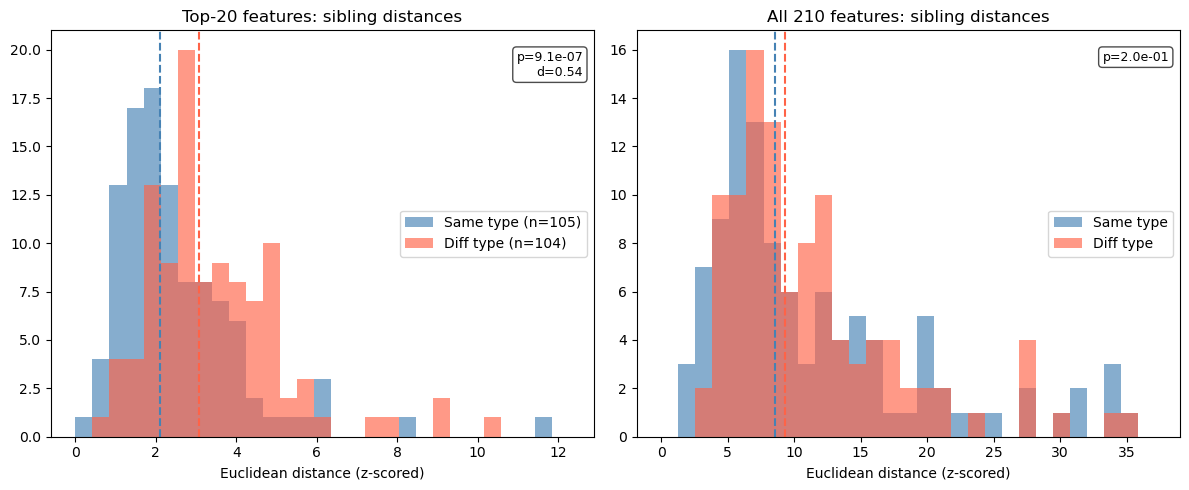


Interpretation: the top-20 selected features DO significantly separate same-type vs diff-type sibling pairs (p=9.08e-07).


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# Pairwise distance sanity check on selected features
# ═══════════════════════════════════════════════════════════════════════════
# Hypothesis: same-type terminal sibling pairs should have SMALLER euclidean
# distance than different-type sibling pairs in the 20 selected-feature space.
# This tests whether the linear-selected features alone form a useful distance
# representation, without any learned embedding.

from scipy.spatial.distance import pdist, cdist, squareform
from scipy.stats import mannwhitneyu

# Build parent→children map from lineage tree
children_dict_lin = defaultdict(list)
def build_family(node, parent_name=None):
    name = map_names(node["did"])
    if parent_name is not None:
        children_dict_lin[parent_name].append(name)
    for child in node.get("children", []):
        build_family(child, name)
build_family(lineage_data)

# Get z-scored selected features for all cells (standardised per feature)
X_sel_z = (X_sel - X_sel.mean(axis=0)) / X_sel.std(axis=0)

# Collect terminal sibling pairs
cell_name_to_idx = {name: i for i, name in enumerate(sample_names)}
terminal_set = set(sample_names[is_terminal])

sibling_pairs = []
for parent, children in children_dict_lin.items():
    term_children = [c for c in children if c in terminal_set]
    for i in range(len(term_children)):
        for j in range(i + 1, len(term_children)):
            a, b = term_children[i], term_children[j]
            type_a = cell_type_dict.get(a)
            type_b = cell_type_dict.get(b)
            if type_a is None or type_b is None:
                continue
            sibling_pairs.append((a, b, type_a == type_b))

same_pairs = [(a, b) for a, b, s in sibling_pairs if s]
diff_pairs = [(a, b) for a, b, s in sibling_pairs if not s]

def pair_dist(a, b):
    return float(np.linalg.norm(
        X_sel_z[cell_name_to_idx[a]] - X_sel_z[cell_name_to_idx[b]]
    ))

same_dists = np.array([pair_dist(a, b) for a, b in same_pairs])
diff_dists = np.array([pair_dist(a, b) for a, b in diff_pairs])

u_stat, p_mw = mannwhitneyu(same_dists, diff_dists, alternative='less')
pooled_std = np.sqrt((np.std(same_dists,ddof=1)**2 + np.std(diff_dists,ddof=1)**2)/2)
cohen_d = (diff_dists.mean() - same_dists.mean()) / pooled_std

print(f"Terminal sibling pairs: same-type={len(same_pairs)}  diff-type={len(diff_pairs)}")
print(f"Same-type distance:  mean={same_dists.mean():.3f}  median={np.median(same_dists):.3f}")
print(f"Diff-type distance:  mean={diff_dists.mean():.3f}  median={np.median(diff_dists):.3f}")
print(f"Mann-Whitney U (same < diff): p={p_mw:.2e}")
print(f"Cohen's d: {cohen_d:.3f}  (effect size: same vs diff separation)")
print(f"Median ratio (diff/same): {np.median(diff_dists)/np.median(same_dists):.3f}")

# Compare: what if we used all 210 features?
X_all_z = (X - X.mean(axis=0)) / X.std(axis=0)
def pair_dist_all(a, b):
    return float(np.linalg.norm(
        X_all_z[cell_name_to_idx[a]] - X_all_z[cell_name_to_idx[b]]
    ))
same_all = np.array([pair_dist_all(a, b) for a, b in same_pairs])
diff_all = np.array([pair_dist_all(a, b) for a, b in diff_pairs])
u_all, p_all = mannwhitneyu(same_all, diff_all, alternative='less')
print(f"\nAll 210 features:  same median={np.median(same_all):.3f}  "
      f"diff median={np.median(diff_all):.3f}  p={p_all:.2e}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bins = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 30)
axes[0].hist(same_dists, bins=bins, alpha=0.65, color='steelblue', label=f'Same type (n={len(same_dists)})')
axes[0].hist(diff_dists, bins=bins, alpha=0.65, color='tomato', label=f'Diff type (n={len(diff_dists)})')
axes[0].axvline(np.median(same_dists), color='steelblue', ls='--')
axes[0].axvline(np.median(diff_dists), color='tomato', ls='--')
axes[0].set_title(f'Top-{K_SELECT} features: sibling distances')
axes[0].set_xlabel('Euclidean distance (z-scored)')
axes[0].legend()
axes[0].text(0.98, 0.95, f'p={p_mw:.1e}\nd={cohen_d:.2f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

bins2 = np.linspace(0, max(same_all.max(), diff_all.max()) * 1.05, 30)
axes[1].hist(same_all, bins=bins2, alpha=0.65, color='steelblue', label=f'Same type')
axes[1].hist(diff_all, bins=bins2, alpha=0.65, color='tomato', label=f'Diff type')
axes[1].axvline(np.median(same_all), color='steelblue', ls='--')
axes[1].axvline(np.median(diff_all), color='tomato', ls='--')
axes[1].set_title('All 210 features: sibling distances')
axes[1].set_xlabel('Euclidean distance (z-scored)')
axes[1].legend()
axes[1].text(0.98, 0.95, f'p={p_all:.1e}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

print(f"\nInterpretation: the top-{K_SELECT} selected features {'DO' if p_mw < 0.01 else 'do NOT'} "
      f"significantly separate same-type vs diff-type sibling pairs (p={p_mw:.2e}).")